# `spectral.py` — Method Testing Notebook

This notebook provides a structured workspace for manually inspecting and testing each function in `clustering/spectral.py`.  
It is intentionally sparse: markdown cells describe *what* each function does and *what to look for*; code cells are left for you to fill in.

**Functions covered (in order)**

| # | Function | Purpose |
|---|----------|---------|
| 1 | `dist_mat` | Pairwise Euclidean distance matrix |
| 2 | `renorm_rows` | Row-wise L² normalisation (Ng–Jordan–Weiss) |
| 3 | `degree_heterogeneity_from_dist` | Degree vector and coefficient of variation from affinity |
| 4 | `cluster_balance_stats` | Balance diagnostics (entropy, Gini) for a label vector |
| 5 | `knn_affinity` | Symmetric k-NN Gaussian affinity matrix |
| 6 | `KM_spec_decom` | Laplacian eigendecomposition (RW or SYM) |
| 7 | `spectral_embed` | End-to-end full-affinity spectral embedding |

---
## Preamble — Imports and Setup

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

from clustering.spectral import (
    dist_mat,
    renorm_rows,
    degree_heterogeneity_from_dist,
    cluster_balance_stats,
    knn_affinity,
    KM_spec_decom,
    spectral_embed,
)
from data.generators import make_blobs_convex, make_two_moons, make_rings

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [ ]:
print(sys.executable)

---
## Data — Generate Reference Datasets

Three datasets are used throughout:

- **Blobs** — well-separated Gaussian clusters; the easy case.  
- **Circles** — concentric rings; not linearly separable.  
- **Moons** — two interleaved half-moons; classic spectral benchmark.

Run this cell once and re-use `X_*` / `y_*` variables in all sections below.

In [ ]:
SEED = 0

X_blobs,   y_blobs   = make_blobs_convex(N=200, num_clusters=3, n_features=2, seed=SEED)
X_circles, y_circles = make_rings(n_points=200, n_circles=3, noise_std=0.05, seed=SEED)
X_moons,   y_moons   = make_two_moons(n_samples=200, noise=0.05, seed=SEED)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, X, y, title in zip(
    axes,
    [X_blobs, X_circles, X_moons],
    [y_blobs, y_circles, y_moons],
    ['Blobs', 'Circles', 'Moons']
):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=10)
    ax.set_title(title)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 1 — `dist_mat`

**What it does:** computes the N × N matrix of pairwise Euclidean distances between all points in X.  
The diagonal is zero (distance from a point to itself); the matrix is symmetric.

**What to check:**
- Shape is `(N, N)`.
- Diagonal is all zeros.
- Matrix is symmetric: `D[i,j] == D[j,i]`.
- All entries are non-negative.

In [27]:
D = dist_mat(X_blobs) # alternate the dataframe

print("Shape:    ", D.shape)
print("Diagonal zeros?   ", np.all(np.diag(D) == 0))
print("Symmetric?        ", np.allclose(D, D.T))
print("All non-negative? ", np.all(D >= 0))
print("\nFirst 5×5 block:\n", np.round(D[:5, :5], 3))

Shape:     (200, 200)
Diagonal zeros?    True
Symmetric?         True
All non-negative?  True

First 5×5 block:
 [[0.    1.194 1.797 0.332 0.701]
 [1.194 0.    1.073 0.911 0.552]
 [1.797 1.073 0.    1.469 1.16 ]
 [0.332 0.911 1.469 0.    0.382]
 [0.701 0.552 1.16  0.382 0.   ]]


---
## 2 — `renorm_rows`

**What it does:** divides each row of a matrix by its L² norm, so every row has unit length after the call.  
This is the Ng–Jordan–Weiss normalisation step applied to eigenvector matrices before clustering.

**What to check:**
- Row norms of the output should all equal 1 (up to floating-point precision).
- Shape is unchanged.
- The `eps` guard prevents division by zero for near-zero rows.

In [28]:
M = np.array([[3.0, 4.0],
              [1.0, 0.0],
              [0.0, 2.0]])

M_norm = renorm_rows(M)

print("Input:\n", M)
print("\nAfter renorm_rows:\n", np.round(M_norm, 4))
print("\nRow norms (should all be 1.0):", np.round(np.linalg.norm(M_norm, axis=1), 10))

Input:
 [[3. 4.]
 [1. 0.]
 [0. 2.]]

After renorm_rows:
 [[0.6 0.8]
 [1.  0. ]
 [0.  1. ]]

Row norms (should all be 1.0): [1. 1. 1.]


---
## 3 — `degree_heterogeneity_from_dist`

**What it does:** builds the full Gaussian affinity W = exp(−D² / 2σ²), then computes:
- `deg` — the degree vector (row sums of W): how *connected* each point is.
- `cv` — coefficient of variation (std / mean): a scalar measure of degree heterogeneity.  
  A high CV means some points are far more connected than others, which can destabilise spectral clustering.

**What to check:**
- `deg` has length N.
- `cv` is a non-negative scalar.
- Try different `sigma` values and observe how CV changes.

In [29]:
sigma_values = [0.1, 0.5, 1.0, 2.0]

print(f"{'sigma':>8}  {'CV':>8}  {'min deg':>10}  {'max deg':>10}  {'mean deg':>10}")
print("-" * 55)
for s in sigma_values:
    deg, cv = degree_heterogeneity_from_dist(X_blobs, sigma=s)
    print(f"{s:>8.1f}  {cv:>8.4f}  {deg.min():>10.4f}  {deg.max():>10.4f}  {deg.mean():>10.4f}")

   sigma        CV     min deg     max deg    mean deg
-------------------------------------------------------
     0.1    1.2124      0.0000      1.8090      0.3818
     0.5    0.4551      0.2654     13.6818      7.8167
     1.0    0.3204      4.4911     37.5674     26.4281
     2.0    0.2402     26.4764    100.9394     72.5119


---
## 4 — `cluster_balance_stats`

**What it does:** given a predicted label vector `y_pred`, computes four balance diagnostics:
- `min_cluster_frac` / `max_cluster_frac` — fraction of points in the smallest / largest cluster.
- `cluster_entropy` — Shannon entropy of cluster sizes; maximised by perfectly equal clusters.
- `cluster_gini` — Gini coefficient of cluster sizes; 0 = balanced, higher = more skewed.

**What to check:**
- Perfect balance: `[0,0,1,1,2,2]` → Gini ≈ 0, entropy is maximal.
- Extreme imbalance: one large cluster and one singleton → high Gini, low entropy.

In [30]:
y_balanced   = np.array([0, 0, 1, 1, 2, 2])
y_imbalanced = np.array([0, 0, 0, 0, 0, 1])

for label, y in [("Balanced  ", y_balanced), ("Imbalanced", y_imbalanced)]:
    stats = cluster_balance_stats(y)
    print(f"{label}  {stats}")

Balanced    {'min_cluster_frac': 0.33333333333327775, 'max_cluster_frac': 0.33333333333327775, 'cluster_entropy': 1.0986122886650933, 'cluster_gini': -7.394085344003543e-14}
Imbalanced  {'min_cluster_frac': 0.16666666666663887, 'max_cluster_frac': 0.8333333333331945, 'cluster_entropy': 0.4505612088643962, 'cluster_gini': 0.3333333333331805}


---
## 5 — `knn_affinity`

### What problem does this solve?

The standard Gaussian affinity matrix connects *every* point to *every* other point, with weight decaying as distance increases.
For well-separated clusters this is fine, but on manifold-shaped data (rings, moons) distant points still receive non-zero weights — the graph "leaks" across cluster boundaries and the Laplacian eigenvectors lose their ability to separate them.

A k-NN graph fixes this: each point only connects to its k nearest neighbours, so edges respect the local geometry of the data.

---



### Sample data

In [33]:
D_moons = dist_mat(X_moons)
n       = D_moons.shape[0]
k       = 5
sigma   = 0.3

In [34]:
print(n)

200


### Step-by-step breakdown



**Step 1 — `np.argsort(dist_matrix, axis=1)`**  
Sorts each row of the distance matrix by ascending distance.  
Column 0 of the result is always the point itself (distance = 0), so the k nearest *other* points occupy columns 1 through k.  
Why `argsort` rather than a KD-tree? For the problem sizes here (N ~ a few hundred) argsort on a precomputed distance matrix is simple and fast enough. A KD-tree would only pay off for very large N.

In [32]:
# --- Step 1: argsort ---
sorted_idx = np.argsort(D_moons, axis=1)   # col 0 = self (dist=0), cols 1:k+1 = neighbours
nn_idx     = sorted_idx[:, 1:k + 1]        # (n, k)

print("Step 1 — sorted_idx[0] (point 0's neighbours by rank):", sorted_idx[0, :k+3])
print("         nn_idx[0]    (its k=5 nearest neighbours):   ", nn_idx[0])

Step 1 — sorted_idx[0] (point 0's neighbours by rank): [  0 192 120  63 152  30 119  55]
         nn_idx[0]    (its k=5 nearest neighbours):    [192 120  63 152  30]


**Step 2 — Build a directed adjacency mask**  
`nn_mask[i, j] = True` if j is among i's k nearest neighbours.  
This is *directed*: i pointing to j does not imply j points back to i.
We make it undirected in step 3

In [ ]:
# --- Step 2: directed mask ---
nn_mask      = np.zeros((n, n), dtype=bool)
rows         = np.repeat(np.arange(n), k)
nn_mask[rows, nn_idx.ravel()] = True # clever way of doing this without a loop

print("\nStep 2 — nn_mask[0] True count (should equal k):", nn_mask[0].sum())


Step 2 — nn_mask[0] True count (should equal k): 5


**Step 3 — OR-symmetrisation: `sym_mask = nn_mask | nn_mask.T`**  
An edge between i and j is kept if *either* i nominated j **or** j nominated i.  
The alternative (AND: keep only mutual nominations) is stricter and risks leaving isolated nodes — particularly near cluster boundaries where the neighbourhood relationship is not reciprocal. OR-symmetrisation guarantees a connected graph and is the standard choice for spectral methods.

In [ ]:
# --- Step 3: OR-symmetrisation ---
sym_mask = nn_mask | nn_mask.T

print("Step 3 — sym_mask[0] True count (k ≤ x ≤ 2k):", sym_mask[0].sum())
print("         Total undirected edges:", sym_mask.sum() // 2,
      f"  (vs {n*(n-1)//2} fully connected)") # waaaay more sparse not, check with Lionel


Step 3 — sym_mask[0] True count (k ≤ x ≤ 2k): 7
         Total undirected edges: 594   (vs 19900 fully connected)


**Step 4 — Apply Gaussian weights**  
The mask selects which edges exist; the weight on each retained edge is `exp(−d² / 2σ²)`.  
Closer neighbours receive higher weights; the kernel decays smoothly to zero with distance.  
Only masked edges are kept (`A = W * sym_mask`), so all non-neighbour pairs are exactly zero.

**Step 5 — Zero the diagonal**  
Self-loops (`A[i,i]`) would inflate the degree of every node and distort the Laplacian — a node would appear more connected than it actually is. They carry no geometric information and are always removed.


In [ ]:
# --- Step 4 & 5: weights + zero diagonal ---
A = knn_affinity(D_moons, k=k, sigma=sigma)

print("\nStep 4/5 — A properties:")
print("  Symmetric?        ", np.allclose(A, A.T))
print("  Diagonal zeros?   ", np.all(np.diag(A) == 0))
print("  All non-negative? ", np.all(A >= 0))
print("  Non-zero entries: ", np.count_nonzero(A), f"  (sparsity: {1 - np.count_nonzero(A)/A.size:.1%})")


Step 4/5 — A properties:
  Symmetric?         True
  Diagonal zeros?    True
  All non-negative?  True
  Non-zero entries:  39800   (sparsity: 0.5%)


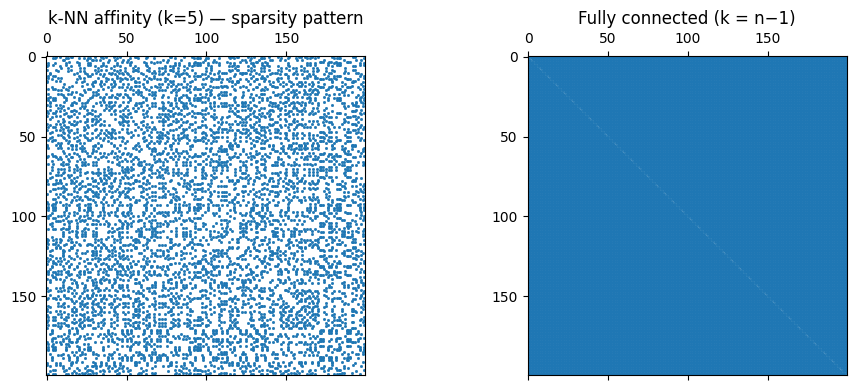

In [ ]:
# --- Visualise sparsity: k=5 vs fully connected ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].spy(A, markersize=1)
axes[0].set_title(f"k-NN affinity (k={k}) — sparsity pattern")

A_full = knn_affinity(D_moons, k=n-1, sigma=sigma)
axes[1].spy(A_full, markersize=1)
axes[1].set_title("Fully connected (k = n−1)")

plt.tight_layout()
plt.show()

### Key quantities to inspect

- **`nn_mask`** — the directed adjacency mask (before symmetrisation); should have exactly k `True` entries per row.
- **`sym_mask`** — after OR: each row has ≥ k and ≤ 2k `True` entries.
- **`A`** — the final affinity: sparse, symmetric, non-negative, zero diagonal.
- **Edge count** — `sym_mask.sum() / 2` gives the number of undirected edges; compare to `n*(n-1)/2` for the fully connected case.

---
## 6 — `KM_spec_decom`

**What it does:** given a pairwise distance matrix, builds the full Gaussian affinity and computes the eigendecomposition of either:
- **RW** (random-walk Laplacian): L = I − D⁻¹W
- **SYM** (symmetric normalised Laplacian): L_sym = I − D^{−1/2} W D^{−1/2}

Returns eigenvalues (ascending), eigenvectors (columns), and the affinity matrix A.

**What to check:**
- Smallest eigenvalue ≈ 0 (constant vector is always in the null space).
- Number of near-zero eigenvalues equals the number of connected components.
- Eigengap: the jump between eigenvalue k and k+1 should be visible for a good σ.

L_RW  smallest 5 eigenvalues: [-0.002091  0.028953  0.084572  0.130371  0.205777]
L_SYM  smallest 5 eigenvalues: [0.       0.031269 0.084049 0.130684 0.207399]


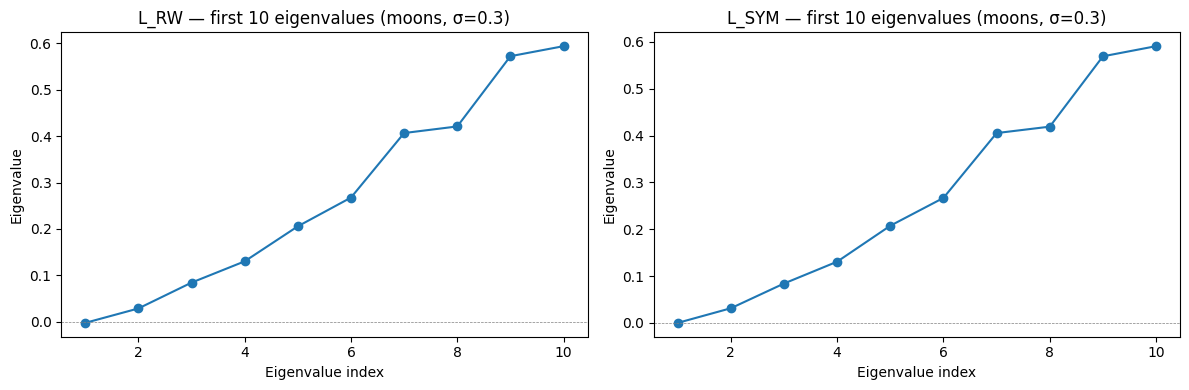

In [56]:
sigma = 0.3
D     = dist_mat(X_moons)
I     = np.eye(len(X_moons))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, lap in zip(axes, ["RW", "SYM"]):
    eig_vals, eig_vecs, A = KM_spec_decom(D, sigma=sigma, Laplacian=lap, I_mat=I)
    ax.plot(np.arange(1, 11), eig_vals[:10], 'o-')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("Eigenvalue")
    ax.set_title(f"L_{lap} — first 10 eigenvalues (moons, σ={sigma})")
    print(f"L_{lap}  smallest 5 eigenvalues: {np.round(eig_vals[:5], 6)}")

plt.tight_layout()
plt.show()

---
## 7 — `spectral_embed`

**What it does:** the full end-to-end pipeline:
1. Computes the distance matrix.
2. Calls `KM_spec_decom` to get eigenvalues and eigenvectors.
3. Selects the first `q` eigenvectors (smallest eigenvalues) as embedding columns.
4. For **SYM** only: applies `renorm_rows` (Ng–Jordan–Weiss step).

Returns Y (N × q embedding) and the full eigenvalue vector.

**What to check:**
- Y shape is `(N, q)`.
- For SYM: rows of Y have unit norm.
- For RW: rows are *not* normalised.
- Plot the 2-D embedding (q=2) coloured by ground-truth label to see cluster separation.

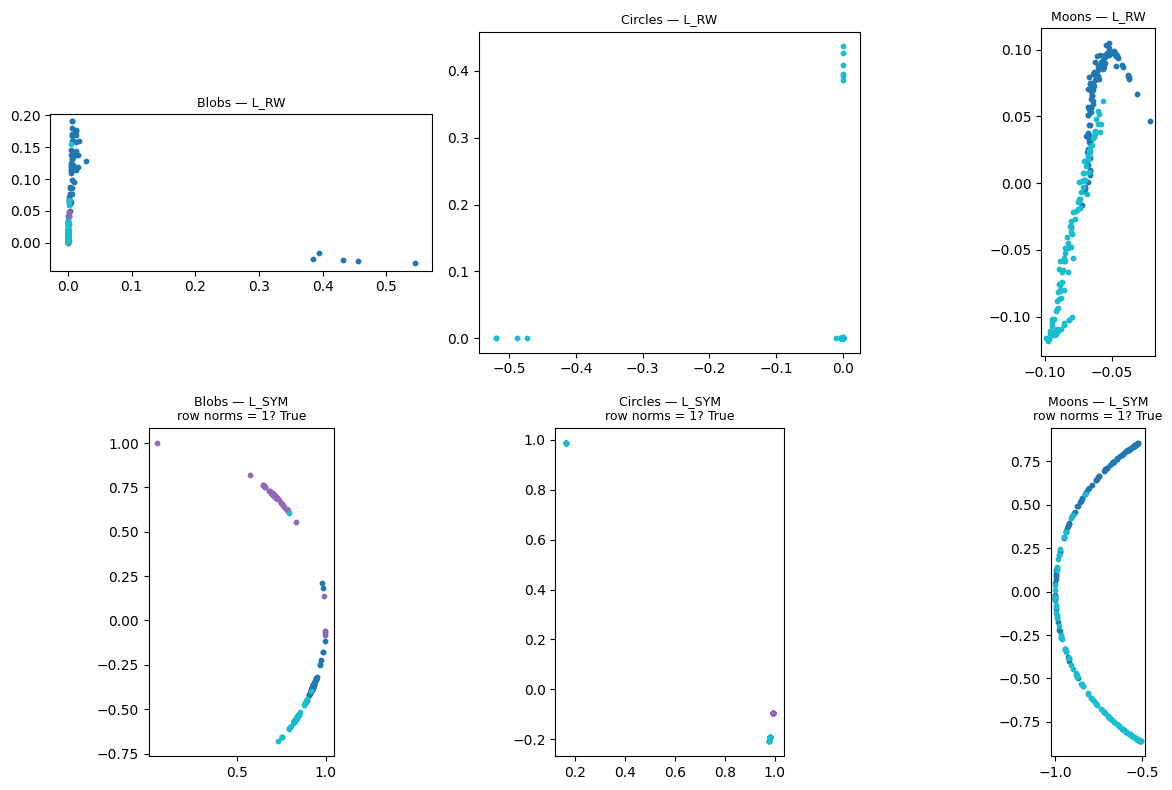

In [57]:
sigma = 0.3
q     = 2

datasets = [
    (X_blobs,   y_blobs,   "Blobs"),
    (X_circles, y_circles, "Circles"),
    (X_moons,   y_moons,   "Moons"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for col, (X, y, name) in enumerate(datasets):
    for row, lap in enumerate(["RW", "SYM"]):
        Y, eig_vals = spectral_embed(X, sigma=sigma, k=2, q=q, Laplacian=lap)

        # Verify row norms
        row_norms = np.linalg.norm(Y, axis=1)
        norm_check = np.allclose(row_norms, 1.0) if lap == "SYM" else True

        ax = axes[row, col]
        unique_labels = np.unique(y)
        colours = plt.cm.tab10(np.linspace(0, 0.9, len(unique_labels)))
        for i, lbl in enumerate(unique_labels):
            mask = y == lbl
            ax.scatter(Y[mask, 0], Y[mask, 1], c=[colours[i]], s=10, label=f"class {lbl}")

        title = f"{name} — L_{lap}"
        if lap == "SYM":
            title += f"\nrow norms = 1? {norm_check}"
        ax.set_title(title, fontsize=9)
        ax.set_aspect('equal')

plt.tight_layout()
plt.show()